# Visualizing the Sensor Model Probability Distribution
This notebook visualizes the combined probability distribution used in the sensor model from `sensor_model.py`. The distribution is a mixture of four components: hit, short, max, and random, as described in Probabilistic Robotics (Thrun et al.).

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Sensor Model Parameters (from sensor_model.py)

In [80]:
# Parameters from sensor_model.py
z_hit = 5
z_short = 0.8
z_max = 0.71
z_rand = 700

sigma_hit = 55
lambda_short = 0.008
max_range = 1000

## Combined Probability Distribution Function
This function computes the combined probability for a given measurement $z_k$ and expected measurement $z_k^*$.

In [81]:
def sensor_model_prob(z_k, z_k_star, z_hit, z_short, z_max, z_rand, sigma_hit, lambda_short, max_range):
    # p_hit: Gaussian
    if 0 <= z_k <= max_range:
        p_hit = norm.pdf(z_k, loc=z_k_star, scale=sigma_hit)
    else:
        p_hit = 0.0
    # p_short: Exponential
    if 0 <= z_k <= z_k_star and z_k_star > 0:
        eta_short = 1.0 / (1.0 - np.exp(-lambda_short * z_k_star))
        p_short = eta_short * lambda_short * np.exp(-lambda_short * z_k)
    else:
        p_short = 0.0
    # p_max: Point mass at max range
    p_max_val = 1.0 if z_k >= max_range else 0.0
    # p_rand: Uniform
    if 0 <= z_k < max_range:
        p_rand = 1.0 / max_range
    else:
        p_rand = 0.0
    # Combined
    p = (z_hit * p_hit + z_short * p_short + z_max * p_max_val + z_rand * p_rand)
    return p

## Plotting the Probability Distribution
We will plot the combined probability for a range of $z_k$ values, for different expected measurements $z_k^*$.

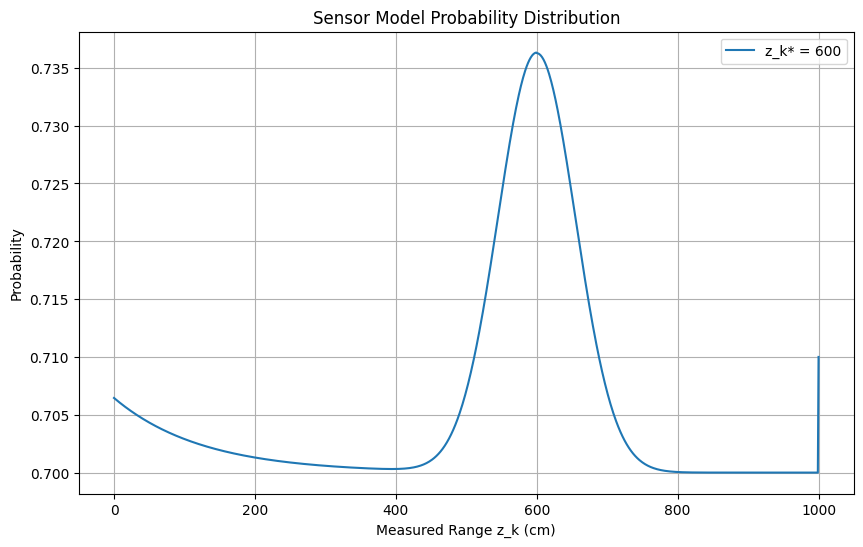

In [82]:
# z_k_stars = [100, 300, 600, 900]  # Example expected measurements
z_k_stars = [600]  # Example expected measurements
z_ks = np.linspace(0, max_range, 1000)
plt.figure(figsize=(10, 6))
for z_k_star in z_k_stars:
    probs = [sensor_model_prob(z_k, z_k_star, z_hit, z_short, z_max, z_rand, sigma_hit, lambda_short, max_range) for z_k in z_ks]
    plt.plot(z_ks, probs, label=f'z_k* = {z_k_star}')
plt.title('Sensor Model Probability Distribution')
plt.xlabel('Measured Range z_k (cm)')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()